# Multi-class Classification

We will use logistic regression to recognize handwritten digits (from 0 to 9). Automated handwritten digit recognition is widely used today - from recognizing zip codes (postal codes) on mail envelopes to recognizing amounts written on bank checks. 


In [1]:
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize

import utils

# tells matplotlib to embed plots within the notebook
%matplotlib inline

## Multi-class Classification

The file `digits_dataset.npz` has 5000 training examples of handwritten digits (This is a subset of the [MNIST](http://yann.lecun.com/exdb/mnist) handwritten digit dataset), where each training example is a 20 pixel by 20 pixel ("unrolled" into a 400-dimensional vector)  grayscale image of the digit. Each pixel is represented by a floating point number indicating the grayscale intensity at that location. Each of these training examples becomes a single row in our data matrix `X`. This gives us a 5000 by 400 matrix `X` where every row is a training example for a handwritten digit image.

$$ X = \begin{bmatrix} - \: (x^{(1)})^T \: - \\ -\: (x^{(2)})^T \:- \\ \vdots \\ - \: (x^{(m)})^T \:-  \end{bmatrix} $$

The second part of the training set is a 5000-dimensional vector `y` that contains labels for the training set. 

In [2]:
# 20x20 Input Images of Digits
input_layer_size  = 400

# 10 labels, from 1 to 10 (note that we have mapped "0" to label 10)
num_labels = 10

#  training data stored in arrays X, y
data = np.load('Data/digits_dataset.npz')

X = data['X']
y = data['y']

m = y.size

print(X.shape)
print(y.shape)
print(np.unique(y))


(5000, 400)
(5000,)
[0 1 2 3 4 5 6 7 8 9]


### Visualizing the data

The `displayData` function maps each row to a 20 pixel by 20 pixel grayscale image and displays the images together.

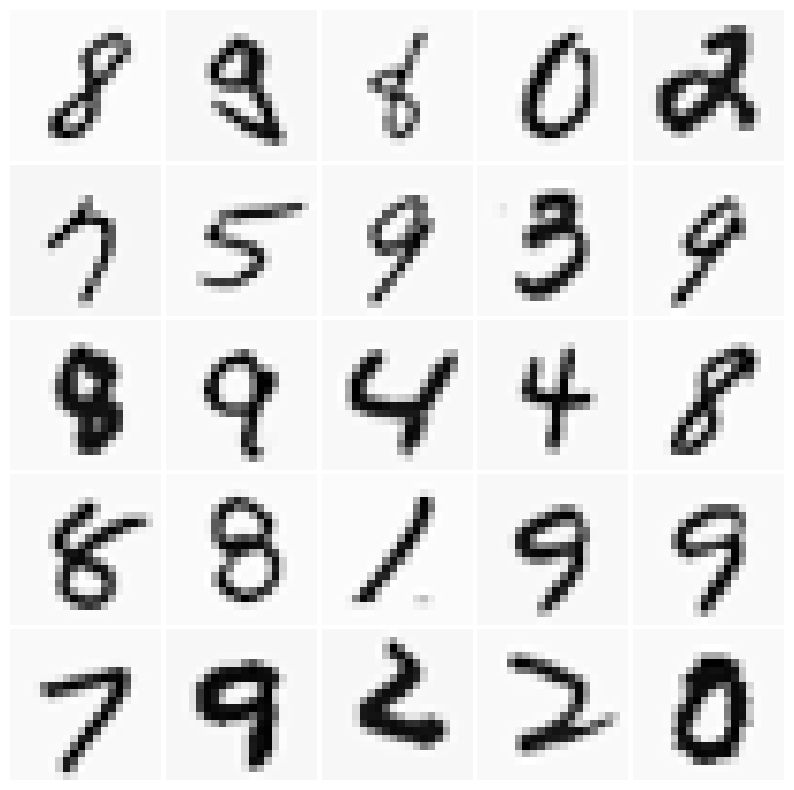

In [3]:
# Randomly select 25 data points to display
rand_indices = np.random.choice(m, 25, replace=False)
sel = X[rand_indices, :]

utils.displayData(sel)

### Vectorizing Logistic Regression

Since there are 10 classes, we need to train 10 separate logistic regression classifiers. For efficience, our code needs to be well vectorized.

In [4]:
# test values for the parameters theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# test values for the inputs
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# test values for the labels
y_t = np.array([1, 0, 1, 0, 1])

# test value for the regularization parameter
lambda_t = 3

#### Vectorizing the Cost Function

In logistic regression, the hypothesis function is defined using the sigmoid:

$$
g(z) = \frac{1}{1+e^{-z}}
$$

For a single example:

$$
h_\theta(x^{(i)}) = g(\theta^T x^{(i)})
$$

Instead of computing this for each example using loops, we can vectorize the operation.

Let:

$$
X =
\begin{bmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T -
\end{bmatrix}
\qquad
\theta =
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_n
\end{bmatrix}
$$

By multiplying the matrix \(X\) by the vector $\theta$, we compute all linear combinations simultaneously:


$$ X\theta = \begin{bmatrix} - \left( x^{(1)} \right)^T\theta - \\ - \left( x^{(2)} \right)^T\theta - \\ \vdots \\ - \left( x^{(m)} \right)^T\theta - \end{bmatrix} = \begin{bmatrix} - \theta^T x^{(1)}  - \\ - \theta^T x^{(2)} - \\ \vdots \\ - \theta^T x^{(m)}  - \end{bmatrix} $$

In the last equality, we used the fact that $a^Tb = b^Ta$ if $a$ and $b$ are vectors. This allows us to compute the products $\theta^T x^{(i)}$ for all our examples $i$ in one line of code.


Applying the sigmoid element-wise gives the vector of predictions:

$$
h = g(X\theta)
$$

---

### Vectorized Cost Function (Unregularized)

In (unregularized) logistic regression, the cost function is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left( h_\theta\left( x^{(i)} \right) \right) - \left(1 - y^{(i)} \right) \log \left(1 - h_\theta \left( x^{(i)} \right) \right) \right] $$

This can be written without summations as:

$$
J(\theta) =
\frac{1}{m}
\left[
-y^T \log(h) - (1-y)^T \log(1-h)
\right]
$$

where \(h = g(X$\theta)$\).

This formulation allows efficient computation using matrix operations instead of explicit loops.


In [5]:
def lr_cost_function(theta, X, y, lambda_):
    """
    Computes the cost of using theta as the parameter for regularized
    logistic regression and the gradient of the cost w.r.t. to the parameters.
    
    Parameters
    ----------
    theta : array_like
        Logistic regression parameters. A vector with shape (n, ). n is 
        the number of features including any intercept.  
    
    X : array_like
        The data set with shape (m x n). m is the number of examples, and
        n is the number of features (including intercept).
    
    y : array_like
        The data labels. A vector with shape (m, ).
    
    lambda_ : float
        The regularization parameter. 
    
    Returns
    -------
    J : float
        The computed value for the regularized cost function. 
    
    grad : array_like
        A vector of shape (n, ) which is the gradient of the cost
        function with respect to theta, at the current values of theta.

    """
    #Initialize some useful values
    m = y.size
    
    # convert labels to ints if their type is bool
    if y.dtype == bool:
        y = y.astype(int)
    
    grad = np.zeros(theta.shape)
    
    h = utils.sigmoid(X.dot(theta)) # hypothesis
    temp = np.copy(theta)
    temp[0] = 0   # because we don't add anything for j = 0

    # Calculating cost
    first_term = -y.dot(np.log(h))  
    second_term = (1-y).dot(np.log(1 - h))
    regularization_cost_term = lambda_/(2*m) * temp.dot(temp)
    J = (1/m) * np.sum(first_term - second_term) + regularization_cost_term

    # Calculating gradient
    grad_unreg = (1/m) * X.T.dot(h - y)
    grad = grad_unreg + (lambda_/m) * temp  # skipping j=0

    return J, grad

#### Vectorizing regularized logistic regression

After implementing vectorization for logistic regression, we will now add regularization to the 
cost function. For regularized logistic regression, the cost function is defined as

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left(h_\theta\left(x^{(i)} \right)\right) - \left( 1 - y^{(i)} \right) \log\left(1 - h_\theta \left(x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Note that you should not be regularizing $\theta_0$ which is used for the bias term.
Correspondingly, the partial derivative of regularized logistic regression cost for $\theta_j$ is defined as

$$
\begin{align*}
& \frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta\left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)}  & \text{for } j = 0 \\
& \frac{\partial J(\theta)}{\partial \theta_j} = \left( \frac{1}{m} \sum_{i=1}^m \left( h_\theta\left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} \right) + \frac{\lambda}{m} \theta_j & \text{for } j  \ge 1
\end{align*}
$$

In [6]:
J, grad = lr_cost_function(theta_t, X_t, y_t, lambda_t)

print('Cost         : {:.6f}'.format(J))
print('-----------------------')
print('Gradients:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))

Cost         : 2.534819
-----------------------
Gradients:
 [0.146561, -0.548558, 0.724722, 1.398003]


### One-vs-all Classification

Now, let's implement one-vs-all classification by training multiple regularized logistic regression classifiers, one for each of the $K$ classes in our dataset. 
Our code return all the classifier parameters in a matrix $\theta \in \mathbb{R}^{K \times (N +1)}$, where each row of $\theta$ corresponds to the learned logistic regression parameters for one class. 

Note that the `y` argument to this function is a vector of labels from 0 to 9. When training the classifier for class $k \in \{0, ..., K-1\}$, we will want a K-dimensional vector of labels $y$, where $y_j \in 0, 1$ indicates whether the $j^{th}$ training instance belongs to class $k$ $(y_j = 1)$, or if it belongs to a different
class $(y_j = 0)$. 

In [7]:
def one_vs_all(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.
    
    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n). m is the number of 
        data points, and n is the number of features. Note that we 
        do not assume that the intercept term (or bias) is in X, however
        we provide the code below to add the bias term to X. 
    
    y : array_like
        The data labels. A vector of shape (m, ).
    
    num_labels : int
        Number of possible labels.
    
    lambda_ : float
        The logistic regularization parameter.
    
    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        (ie. `numlabels`) and n is number of features without the bias.
    
    """
    # Some useful variables
    m, n = X.shape
    
    # You need to return the following variables correctly 
    all_theta = np.zeros((num_labels, n + 1))

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
      
        # Set options for minimize
        options = {'maxfun': 50}
        # Run minimize to obtain the optimal theta. This function will 
        # return a class object where theta is in `res.x` and cost in `res.fun`
        res = optimize.minimize(lr_cost_function, 
                            initial_theta, 
                            (X, (y == c), lambda_), 
                            jac=True, 
                            method='TNC',
                            options=options) 
        all_theta[c] = res.x

    return all_theta

In [8]:
lambda_ = 0.1
all_theta = one_vs_all(X, y, num_labels, lambda_)

#### One-vs-all Prediction

After training the one-vs-all classifier, we can now use it to predict the digit contained in a given image. For each input, we compute the “probability” that it belongs to each class using the trained logistic regression classifiers. 

In [9]:
def predict_one_vs_all(all_theta, X):
    """
    Return a vector of predictions for each example in the matrix X. 
    Note that X contains the examples in rows. all_theta is a matrix where
    the i-th row is a trained logistic regression theta vector for the 
    i-th class. You should set p to a vector of values from 0..K-1 
    (e.g., p = [0, 2, 0, 1] predicts classes 0, 2, 0, 1 for 4 examples) .
    
    Parameters
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.
    
    X : array_like
        Data points to predict their labels. This is a matrix of shape 
        (m x n) where m is number of data points to predict, and n is number 
        of features without the bias term. Note we add the bias term for X in 
        this function. 
    
    Returns
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # X has all the examples, while all_theta has one row per class with its parameters.
    # When we multiply them, we get a table where each row has one score per class.
    # The probability of each class is obtained by applying the sigmoid to each class’s score (we get a number between 0 and 1), 
    # and then we pick the class with the highest probability.
    p  = np.argmax(utils.sigmoid(X.dot(all_theta.T)), axis=1)
    
    # ============================================================
    return p

Call your `predict_one_vs_all` function using the learned value of $\theta$. You should see that the training set accuracy is about 95.1% (i.e., it classifies 95.1% of the examples in the training set correctly).

In [10]:
pred = predict_one_vs_all(all_theta, X)
print('Training Set Accuracy: {:.2f}%'.format(np.mean(pred == y) * 100))

Training Set Accuracy: 95.38%


(5000, 400)
(5000,)
[0 1 2 3 4 5 6 7 8 9]


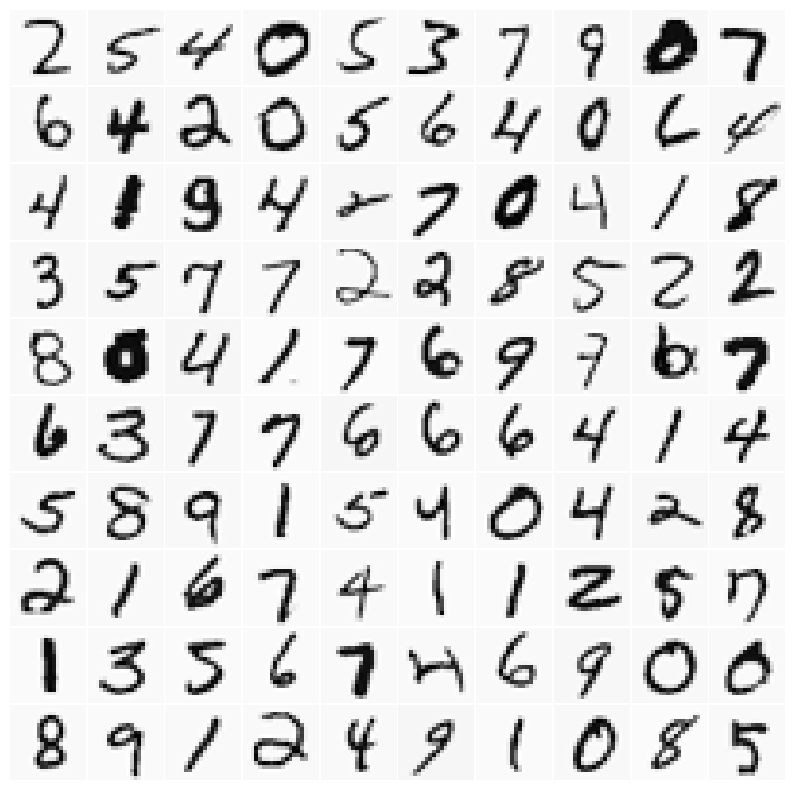

In [11]:
#  training data stored in arrays X, y
data = np.load('Data/digits_dataset.npz')

X = data['X']
y = data['y']

m = y.size

print(X.shape)
print(y.shape)
print(np.unique(y))

# get number of examples in dataset
m = y.size

# randomly permute examples, to be used for visualizing one 
# picture at a time
indices = np.random.permutation(m)

# Randomly select 100 data points to display
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

utils.displayData(sel)